In [ ]:
import re
import random
from tqdm.notebook import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# READ IN DATA

In [ ]:
all_stats = pd.read_csv("data/tfam_array_all_stats.csv", index_col=[0,1], skipinitialspace=True, low_memory=False)
all_stats.head()

raw_mean  raw_median      raw_std  raw_std_percent  \
name        condition                                                       
ATP6_100_o1 ctrl_30      6678.1      6090.5  1143.436385        18.774097   
            uv_30       20787.1     22154.0  4584.957711        20.695846   
            ctrl_300     8862.1      9808.0  2534.278265        25.838889   
            uv_300      34395.6     34876.0  2345.630273         6.725629   
ATP6_100_o2 ctrl_30     11523.3     11679.0  1288.036840        11.028657   

                           raw_sem  raw_sem_percent  raw_variance_coefficient  \
name        condition                                                           
ATP6_100_o1 ctrl_30     361.586334         5.936891                  0.171222   
            uv_30      1449.890934         6.544601                  0.220567   
            ctrl_300    801.409154         8.170974                  0.285968   
            uv_300      741.753421         2.126831                  0.068196   
ATP6_100_o2 ctrl_30     407.313012         3.487568                  0.111777   

                       raw_mean_z  raw_median_z     norm_mean  ...  mid_coord  \
name        condition                                          ...              
ATP6_100_o1 ctrl_30      4.173026      3.906550   6450.989200  ...     8727.0   
            uv_30        0.136003      0.225967  20328.020609  ...     8727.0   
            ctrl_300     4.390684      4.642301   8098.237680  ...     8727.0   
            uv_300       2.174850      2.289422  33988.129304  ...     8727.0   
ATP6_100_o2 ctrl_30     13.522224     13.323943  11510.808570  ...     8727.0   

                       tt  tc  ct  cc     at     gc  g10g_count  g10g_start  \
name        condition                                                         
ATP6_100_o1 ctrl_30     4   5   7   3  58.82  41.18           0          -1   
            uv_30       4   5   7   3  58.82  41.18           0          -1   
            ctrl_300    4   5   7   3  58.82  41.18           0          -1   
            uv_300      4   5   7   3  58.82  41.18           0          -1   
ATP6_100_o2 ctrl_30     4   6   7   3  58.82  41.18           2          29   

                        g10g  
name        condition         
ATP6_100_o1 ctrl_30    False  
            uv_30      False  
            ctrl_300   False  
            uv_300     False  
ATP6_100_o2 ctrl_30     True  

[5 rows x 32 columns]

# Binding profile across mito genome
If it binds specifically, we would expect multiple probes to be intense back to back

In [3]:
genome = all_stats[all_stats["start_coord"] > 0].copy(deep=True)
genome = genome[[(not str(i[0]).lower().endswith("_a")) and (not str(i[0]).lower().endswith("_g")) and (not str(i[0]).lower().endswith("_t")) for i in genome.index]]
genes = [str(i[0]).split("_")[0] for i in genome.index]
genome["gene"] = genes
f_genome = genome[["_o1" in str(i[0]) for i in genome.index]]
r_genome = genome[["_o2" in str(i[0]) for i in genome.index]]
f_genome.head()

raw_mean  raw_median      raw_std  raw_std_percent  \
name        condition                                                       
ATP6_100_o1 ctrl_30      6678.1      6090.5  1143.436385        18.774097   
            uv_30       20787.1     22154.0  4584.957711        20.695846   
            ctrl_300     8862.1      9808.0  2534.278265        25.838889   
            uv_300      34395.6     34876.0  2345.630273         6.725629   
ATP6_101_o1 ctrl_30      6716.7      6860.0  1473.154970        21.474562   

                           raw_sem  raw_sem_percent  raw_variance_coefficient  \
name        condition                                                           
ATP6_100_o1 ctrl_30     361.586334         5.936891                  0.171222   
            uv_30      1449.890934         6.544601                  0.220567   
            ctrl_300    801.409154         8.170974                  0.285968   
            uv_300      741.753421         2.126831                  0.068196   
ATP6_101_o1 ctrl_30     465.852505         6.790853                  0.219327   

                       raw_mean_z  raw_median_z     norm_mean  ...  tt  tc  \
name        condition                                          ...           
ATP6_100_o1 ctrl_30      4.173026      3.906550   6450.989200  ...   4   5   
            uv_30        0.136003      0.225967  20328.020609  ...   4   5   
            ctrl_300     4.390684      4.642301   8098.237680  ...   4   5   
            uv_300       2.174850      2.289422  33988.129304  ...   4   5   
ATP6_101_o1 ctrl_30      4.504655      4.143215   6630.467861  ...   4   5   

                       ct  cc     at     gc  g10g_count  g10g_start   g10g  \
name        condition                                                        
ATP6_100_o1 ctrl_30     7   3  58.82  41.18           0          -1  False   
            uv_30       7   3  58.82  41.18           0          -1  False   
            ctrl_300    7   3  58.82  41.18           0          -1  False   
            uv_300      7   3  58.82  41.18           0          -1  False   
ATP6_101_o1 ctrl_30     7   3  61.76  38.24           0          -1  False   

                       gene  
name        condition        
ATP6_100_o1 ctrl_30    ATP6  
            uv_30      ATP6  
            ctrl_300   ATP6  
            uv_300     ATP6  
ATP6_101_o1 ctrl_30    ATP6  

[5 rows x 33 columns]

In [4]:
c30_f = f_genome.xs("ctrl_30", level=1).sort_values(by="mid_coord")
uv30_f = f_genome.xs("uv_30", level=1).sort_values(by="mid_coord")
c300_f = f_genome.xs("ctrl_300", level=1).sort_values(by="mid_coord")
uv300_f = f_genome.xs("uv_300", level=1).sort_values(by="mid_coord")

c30_r = r_genome.xs("ctrl_30", level=1).sort_values(by="mid_coord")
uv30_r = r_genome.xs("uv_30", level=1).sort_values(by="mid_coord")
c300_r = r_genome.xs("ctrl_300", level=1).sort_values(by="mid_coord")
uv300_r = r_genome.xs("uv_300", level=1).sort_values(by="mid_coord")

c30_f.head()

,raw_mean,raw_median,raw_std,raw_std_percent,raw_sem,raw_sem_percent,raw_variance_coefficient,raw_mean_z,raw_median_z,norm_mean,...,tt,tc,ct,cc,at,gc,g10g_count,g10g_start,g10g,gene
name,,,,,,,,,,,,,,,,,,,,,
D-loop_554_o1,4739.5,4806.0,855.244117,17.795342,270.451937,5.627381,0.180450,0.889854,0.606488,4674.124608,...,1,7,3,5,52.94,47.06,5,3,True,D-loop
D-loop_555_o1,4600.5,4596.5,467.995311,10.181558,147.993112,3.219691,0.101727,1.008136,1.050436,4738.139183,...,0,8,4,5,50.00,50.00,4,1,True,D-loop
D-loop_556_o1,4653.5,4699.0,757.054416,16.110969,239.401627,5.094736,0.162685,0.858936,0.801007,4657.391863,...,0,7,3,5,52.94,47.06,4,7,True,D-loop
D-loop_557_o1,5184.7,5281.5,563.776364,10.674550,178.281740,3.375589,0.108738,1.875717,1.735524,5207.676959,...,1,6,3,5,55.88,44.12,3,5,True,D-loop
D-loop_558_o1,4460.9,4353.0,442.972146,10.176250,140.080092,3.218013,0.099301,0.588126,0.579729,4510.828188,...,2,5,3,6,52.94,47.06,5,3,True,D-loop


## Isaac data
High and low affinity sites were provided by the authors as single coordinates at centers of contig regions identified by their Hidden Markov model. We manually identified the contig region bounds using the supplemental K1/2 data from that paper.
- high affinity sites: `data/footprinting_comparison/TFAM_highAffinity.csv`
- low affinity sites: `data/footprinting_comparison/TFAM_lowAffinity.csv`

In [5]:
# High and low regions manually identified in Isaac data
# key: center coord
# val: (lower bound, upper bound)
low_regions = {
    2723: (2719, 2725),
    3011: (3005, 3014),
    3590: (3583, 3598),
    5210: (5203, 5216),
    5324: (5318, 5328),
    5446: (5440, 5457),
    5900: (5891, 5901),
    6022: (6016, 6024),
    6227: (6224, 6244),
    6343: (6341, 6347),
    6581: (6574, 6587),
    6770: (6769, 6771),
    7223: (7216, 7230),
    7495: (7489, 7500),
    7814: (7805, 7822),
    7858: (7856, 7859),
    7985: (7979, 7988),
    8205: (8204, 8210),
    8784: (8779, 8792),
    8839: (8835, 8842),
    9272: (9270, 9274),
    9619: (9618, 9623),
    10550: (10540, 10553),
    11427: (11417, 11440),
    11780: (11775, 11791),
    12092: (12082, 12095),
    12887: (12883, 12896),
    13028: (13019, 13038),
    13065: (13056, 13075),
    13101: (13100, 13102),
}

high_regions = {
    2574: (2558, 2589),
    2670: (2658, 2680),
    2753: (2734, 2771),
    2864: (2851, 2877),
    2898: (2882, 2912),
    3106: (3092, 3116),
    3385: (3378, 3387),
    3404: (3390, 3417),
    4608: (4598, 4617),
    5252: (5241, 5256),
    5280: (5269, 5289),
    5507: (5492, 5521),
    5581: (5568, 5587),
    5694: (5686, 5703),
    6684: (6680, 6685),
    7521: (7507, 7534),
    7554: (7538, 7569),
    8237: (8218, 8254),
    8505: (8495, 8514),
    9008: (9000, 9019),
    10270: (10258, 10281),
    10422: (10404, 10423),
    10469: (10457, 10493),
    10886: (10876, 10894),
    11474: (11458, 11488),
    12146: (12134, 12156),
    13396: (13379, 13411)
}



# Overlapping

In [6]:
def merge_fwd_rev(fwd_df, rev_df):
    # Make a copy for safe editing
    fwd_copy = fwd_df.copy()
    rev_copy = rev_df.copy()

    # Reset index to remove orientations for later merging
    fwd_copy.index =  fwd_copy.index.map(lambda x: re.sub("_o1", "", x))
    rev_copy.index =  rev_copy.index.map(lambda x: re.sub("_o2", "", x))
    
    # Join on names
    # _r suffix means reverse direction, and no suffix is _f
    joined = fwd_copy.join(rev_copy, how='inner', rsuffix = "_r")

    # Find maximum of forward and reverse probes for same name
    joined["max_norm_median"] = np.zeros((len(joined),1))
    joined["max_sequence"] = joined["sequence"] # Max sequence is the sequence of the f or r probe with maximum fluorescence
    joined["max_dir"] = joined["sequence"] # Direction of probe with max fluorescence
    
    for i, row in joined.iterrows():
        if row["norm_median"] > row["norm_median_r"]:
            joined.at[i, "max_norm_median"] = row["norm_median"]
            joined.at[i, "max_sequence"] = row["sequence"][:33]
            joined.at[i, "max_dir"] = "f"
        else:
            joined.at[i, "max_norm_median"] = row["norm_median_r"]
            joined.at[i, "max_sequence"] = row["sequence_r"][:33]
            joined.at[i, "max_dir"] = "r"

    return joined

In [7]:
# We use control 30 TFAM level for this analysis
c30_joined = merge_fwd_rev(c30_f, c30_r)

# The bed file for the dgfs use coordinates starting at zero and the PBM coordinates
# start at 1. I am only using start and ends coords in this analysis, so I
# subtract 1 from both data series to match the bed file coordinate system.
# c30_joined["start_coord"] += -1
# c30_joined["end_coord"] += -1

c30_joined.head()

,raw_mean,raw_median,raw_std,raw_std_percent,raw_sem,raw_sem_percent,raw_variance_coefficient,raw_mean_z,raw_median_z,norm_mean,...,cc_r,at_r,gc_r,g10g_count_r,g10g_start_r,g10g_r,gene_r,max_norm_median,max_sequence,max_dir
name,,,,,,,,,,,,,,,,,,,,,
D-loop_554,4739.5,4806.0,855.244117,17.795342,270.451937,5.627381,0.180450,0.889854,0.606488,4674.124608,...,4,52.94,47.06,5,1,True,D-loop,4520.765934,TAAGACATCACGATGGATCACAGGTCTATCACC,f
D-loop_555,4600.5,4596.5,467.995311,10.181558,147.993112,3.219691,0.101727,1.008136,1.050436,4738.139183,...,5,50.00,50.00,5,3,True,D-loop,4761.031946,AGACATCACGATGGATCACAGGTCTATCACCCT,f
D-loop_556,4653.5,4699.0,757.054416,16.110969,239.401627,5.094736,0.162685,0.858936,0.801007,4657.391863,...,5,52.94,47.06,5,5,True,D-loop,4790.057876,ATAGGGTGATAGACCTGTGATCCATCGTGATGT,r
D-loop_557,5184.7,5281.5,563.776364,10.674550,178.281740,3.375589,0.108738,1.875717,1.735524,5207.676959,...,5,55.88,44.12,3,7,True,D-loop,5131.804119,ATCACGATGGATCACAGGTCTATCACCCTATTA,f
D-loop_558,4460.9,4353.0,442.972146,10.176250,140.080092,3.218013,0.099301,0.588126,0.579729,4510.828188,...,5,52.94,47.06,4,0,True,D-loop,6222.443033,GTTAATAGGGTGATAGACCTGTGATCCATCGTG,r


## High affinity

In [8]:
# High/low coords are midpoints in stretch of high/low Kds. We will assume 1 binding site, so +/- 11
# high_affinity
hf_coords = [[coord[0], coord[1]] for coord in high_regions.values()]

# Iterate over c30 and designate values as in or out of TFAM intervals
in_vals_f = [] # Adjusted forward Alexa values for probes entirely overlapping bedGraph intervals
out_vals_f = [] # Adjusted forward Alexa values for probes not overlapping bedGraph intervals
in_vals_r = [] # Adjusted reverse Alexa values for probes entirely overlapping bedGraph intervals
out_vals_r = [] # Adjusted reverse Alexa values for probes not overlapping bedGraph intervals
in_vals_max = [] # Same data structure for max between f and r
out_vals_max = []
for index, row in c30_joined.iterrows():
    inb = False
    for interval in hf_coords:
        # Normal case- can disregard circular case in both the probes and the bedGraph intervals because we know there are no circular bedGraph intervals that span the end and beginning of the mitochondrial genome coordinates, so it is not possible for any circular probes to be entirely contained in a bedGraph interval.
        if interval[0] < interval[1]:
            if ((row['start_coord'] >= interval[0] and row['end_coord'] <= interval[1]) or (interval[0] >= row['start_coord'] and interval[1] <= row['end_coord'])) and row['start_coord'] < row['end_coord']:
                inb = True
                break
            
    if inb:
        in_vals_f.append(row['norm_median'])
        in_vals_r.append(row['norm_median_r'])
        in_vals_max.append(row['max_norm_median'])
    else:
        out_vals_f.append(row['norm_median'])
        out_vals_r.append(row['norm_median_r'])
        out_vals_max.append(row['max_norm_median'])

In [9]:
# Some checks
print(len(in_vals_f))
print(len(out_vals_f))
print(in_vals_f[:5])
        
print(len(in_vals_r))
print(len(out_vals_r))
print(in_vals_r[:5])

print(len(in_vals_max))
print(len(out_vals_max))
print(in_vals_max[:5])

136
8149
[6437.76410228677, 5902.292314672155, 5736.134236461585, 8136.544850583101, 6889.81770661908]
136
8149
[4098.073422326055, 5982.62707452358, 6895.754983333045, 5319.430256022195, 5677.720374357445]
136
8149
[6437.76410228677, 5982.62707452358, 6895.754983333045, 8136.544850583101, 6889.81770661908]


In [10]:
# Get length distribution of dgf coordinates
length_dist = []
for i in hf_coords:
    length_dist.append(i[1] + 1 - i[0])

# Find minimum separation between dgf regions
min_sep = 2000
for i in range(len(hf_coords)):
    if i == 0:
        prev_co = hf_coords[i][1]
        continue
    else:
        diff = hf_coords[i][0] - prev_co
        prev_co = hf_coords[i][1]
        
        # Update min if necessary
        if diff < min_sep:
            min_sep = diff

# handle circular case
diff = (hf_coords[0][0]) + (16569 - prev_co)
if diff < min_sep:
    min_sep = diff

In [11]:
# Run simulations
num_trials = 1000 # Number of null trials to run
null_means_max = [] # Contains the null distribution of mean values for max fluorescence
null_means_f = [] # Same for forward 
null_means_r = [] 
for j in tqdm(range(num_trials)):
    # Construct simulated data set
    sample = [] 
    for i in range(len(length_dist)):
        
        # Need region that is not overlapping other regions and not within min separation
        good_pick = False
        while good_pick == False:
            good_pick = True
            region_len = length_dist[i] # Length of this simulated region

            index1 = random.randint(0,16569 - 1)
            # Use Isaac region
            # index1 = random.randint(2500, 14400 - region_len)
            index2 = index1 + region_len - 1
            
            # Handle circular case
            if index2 > 16568:
                index2 = index2 - 16568 - 1
            
            # Check for overlap by looking over regions already in sample
            for t in sample:
                
                 # Index and region are circular- not possible to not overlap
                if t[0] > t[1] and index1 > index2:
                    good_pick = False
                    break
                    
                # Both non-circular
                elif t[0] < t[1] and index1 < index2:
                    # Overlap cases
                    if index1 >= t[0] - min_sep and index1 <= t[1] + min_sep:
                        good_pick = False
                        break
                    elif index2 >= t[0] - min_sep and index2 <= t[1] + min_sep:
                        good_pick = False
                        break

                    # Existing region is fully inside of new region
                    elif index1 <= t[0] and index2 >= t[1]:
                        good_pick = False
                        break
                
                # Region is non-circular and index is circular
                elif t[0] < t[1] and index1 > index2:
                    # Overlap cases
                    if index1 >= t[0] and index1 <= t[1] + min_sep:
                        good_pick = False
                        break
                        
                    elif index2 >= t[0] - min_sep and index2 <= t[1]:
                        good_pick = False
                        break

                    # Existing region is fully inside of new region
                    elif (index1 <= t[0] and t[1] <= 16568) or (t[0] >= 0 and t[1] <= index2):
                        good_pick = False
                        break
                
                # Region is circular and index is non-circular
                elif t[0] > t[1] and index1 < index2:
                    # Overlap cases
                    if (index1 >= t[0] - min_sep and index1 <= 16568) or (index1 >= 0 and index1 <= t[1] + min_sep):
                        good_pick = False
                        break
                        
                    elif (index2 >= t[0] - min_sep and index2 <= 16568):
                        good_pick = False
                        break

                    # Existing region is fully inside of new region- not possible

        sample.append([index1, index2])

    # Now find probes that fully overlap these regions
    in_vals_max_null = [] # Adjusted Alexa values for max probes entirely overlapping bedGraph intervals
    out_vals_max_null = [] # Adjusted Alexa values for max probes not overlapping bedGraph intervals
    in_vals_f_null = [] # Adjusted Alexa values for f probes entirely overlapping bedGraph intervals
    out_vals_f_null = [] # Adjusted Alexa values for f probes not overlapping bedGraph intervals
    in_vals_r_null = [] # Adjusted Alexa values for r probes entirely overlapping bedGraph intervals
    out_vals_r_null = [] # Adjusted Alexa values for r probes not overlapping bedGraph intervals

    for index, row in c30_joined.iterrows():
        inb = False
        for interval in sample:
            # Normal interval, normal probe
            if interval[0] < interval[1] and row['start_coord'] < row['end_coord']:
                if (row['start_coord'] >= interval[0] and row['end_coord'] <= interval[1]) or (interval[0] >= row['start_coord'] and interval[1] <= row['end_coord']):
                    inb = True
                    break
            
            # Circular interval, circular probe
            elif interval[1] < interval[0] and row['start_coord'] > row['end_coord']:
                # Probe inside interval
                if row['start_coord'] >= interval[0] and row['end_coord'] <= interval[1]:
                    inb = True
                    break
                    
                # Interval inside probe- not possible in this dataset because no interval is less than 33 nt
                if interval[0] >= row['start_coord'] and interval[1] <= row['end_coord']:
                    inb = True
                    break
            
            # Circular interval, normal probe
            elif interval[1] < interval[0] and row['start_coord'] < row['end_coord']:
                # Probe inside of interval on high end
                if row['start_coord'] >= interval[0] and row['start_coord'] <= 16568:
                    inb = True
                    break
                    
                if row['end_coord'] >= 0 and row['end_coord'] <= interval[1]:
                    inb = True
                    break
                    
            # Normal interval, circular probe is not possible if the probe must be fully inside of the interval

        if inb:
            in_vals_max_null.append(row['max_norm_median'])
            in_vals_f_null.append(row['norm_median'])
            in_vals_r_null.append(row['norm_median_r'])
        else:
            out_vals_max_null.append(row['max_norm_median'])
            out_vals_f_null.append(row['norm_median'])
            out_vals_r_null.append(row['norm_median_r'])
            
    null_means_max.append(np.mean(in_vals_max_null))
    null_means_f.append(np.mean(in_vals_f_null))
    null_means_r.append(np.mean(in_vals_r_null))



  0%|          | 0/1000 [00:00<?, ?it/s]

KeyboardInterrupt: 

[7330.83066856 7531.2027593  7874.78074605]
7270.558855063486


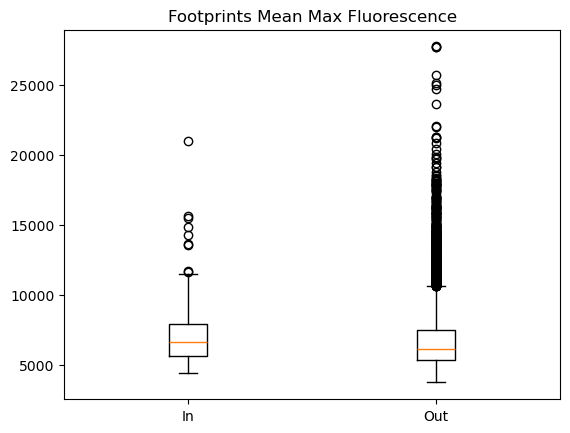

In [ ]:
with open("data/high_affinity_null_means_max.txt", "r") as f:
    null_means_max = [float(x.strip()) for x in f.readlines()]

with open("data/high_affinity_in_probes_vals.txt", "r") as f:
    in_vals_max = [float(x.strip()) for x in f.readlines()]

with open("data/high_affinity_out_probes_vals.txt", "r") as f:
    out_vals_max = [float(x.strip()) for x in f.readlines()]

# In this analysis we are prioritizing the null distribution of the max of the two orientations
print(np.percentile(null_means_max, [90,95,99]))
print(np.mean(in_vals_max))

# Save data to files
# with open("high_affinity_null_means_max.txt", "w") as out_file:
#    for x in null_means_max:
#        out_file.write(str(x) + "\n")

# with open("high_affinity_in_probes_vals.txt", "w") as out_file:
#    for x in in_vals_max:
#        out_file.write(str(x) + "\n")

# with open("high_affinity_out_probes_vals.txt", "w") as out_file:
#    for x in out_vals_max:
#        out_file.write(str(x) + "\n")

# Make a boxplot
plt.boxplot([in_vals_max, out_vals_max], labels = ["In", "Out"])
plt.title("Footprints Mean Max Fluorescence")
# plt.savefig("high_affinity_figure1.png")
plt.show()

In [279]:
# Print some additional statistics
print(np.mean(in_vals_max))
print(np.mean(out_vals_max))
print(np.mean(in_vals_max) - np.mean(out_vals_max))

7270.558855063486
6829.859710918302
440.6991441451837


In [ ]:
# high p value
null_greater_count = 0
for m in null_means_max:
    if m > np.mean(in_vals_max):
        null_greater_count += 1

print(null_greater_count / 1000)

0.081


/Users/satusky/anaconda3/envs/data/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


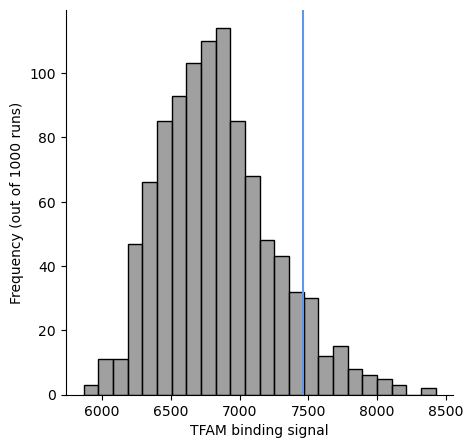

In [ ]:
# Make main histogram plot
fig, ax = plt.subplots(figsize=(5, 5))
h = sns.histplot(null_means_max, ax=ax, color="grey")
ax.axvline(np.mean(in_vals_max),color='cornflowerblue')
ax.set(xlabel="TFAM binding signal", ylabel="Frequency (out of 1000 runs)")
ax.spines[['right', 'top']].set_visible(False)
# plt.title("Maximum Median Adjusted Alexa488 Value")
# plt.legend(["Mean of In Probes", "Null Distribution"])
# plt.savefig("high_affinity_random_distribution.svg")
plt.show()

## Low affinity

In [120]:
# High/low coords are midpoints in stretch of high/low Kds. We will assume 1 binding site, so +/- 11
# high_affinity
lf_coords = [[coord[0], coord[1]] for coord in low_regions.values()]

# Iterate over c30 and designate values as in or out of TFAM intervals
in_vals_f = [] # Adjusted forward Alexa values for probes entirely overlapping bedGraph intervals
out_vals_f = [] # Adjusted forward Alexa values for probes not overlapping bedGraph intervals
in_vals_r = [] # Adjusted reverse Alexa values for probes entirely overlapping bedGraph intervals
out_vals_r = [] # Adjusted reverse Alexa values for probes not overlapping bedGraph intervals
in_vals_max = [] # Same data structure for max between f and r
out_vals_max = []
for index, row in c30_joined.iterrows():
    inb = False
    for interval in lf_coords:
        # Normal case- can disregard circular case in both the probes and the bedGraph intervals because we know there are no circular bedGraph intervals that span the end and beginning of the mitochondrial genome coordinates, so it is not possible for any circular probes to be entirely contained in a bedGraph interval.
        if interval[0] < interval[1]:
            if ((row['start_coord'] >= interval[0] and row['end_coord'] <= interval[1]) or (interval[0] >= row['start_coord'] and interval[1] <= row['end_coord'])) and row['start_coord'] < row['end_coord']:
                inb = True
                break
            
    if inb:
        in_vals_f.append(row['norm_median'])
        in_vals_r.append(row['norm_median_r'])
        in_vals_max.append(row['max_norm_median'])
    else:
        out_vals_f.append(row['norm_median'])
        out_vals_r.append(row['norm_median_r'])
        out_vals_max.append(row['max_norm_median'])

In [121]:
# Some checks
print(len(in_vals_f))
print(len(out_vals_f))
print(in_vals_f[:5])
        
print(len(in_vals_r))
print(len(out_vals_r))
print(in_vals_r[:5])

print(len(in_vals_max))
print(len(out_vals_max))
print(in_vals_max[:5])

326
7959
[5706.53755978859, 5637.41958414786, 5474.46931483927, 5203.7052852129655, 6563.882122809765]
326
7959
[4936.93274446303, 4996.842268585129, 4141.39498345981, 5008.7704752888, 5057.47285542538]
326
7959
[5706.53755978859, 5637.41958414786, 5474.46931483927, 5203.7052852129655, 6563.882122809765]


In [122]:
# Get length distribution of dgf coordinates
length_dist = []
for i in lf_coords:
    length_dist.append(i[1] + 1 - i[0])

# Find minimum separation between dgf regions
min_sep = 2000
for i in range(len(lf_coords)):
    if i == 0:
        prev_co = lf_coords[i][1]
        continue
    else:
        diff = lf_coords[i][0] - prev_co
        prev_co = lf_coords[i][1]
        
        # Update min if necessary
        if diff < min_sep:
            min_sep = diff

# handle circular case
diff = (lf_coords[0][0]) + (16569 - prev_co)
if diff < min_sep:
    min_sep = diff

In [123]:
# Run simulations
num_trials = 1000 # Number of null trials to run
null_means_max = [] # Contains the null distribution of mean values for max fluorescence
null_means_f = [] # Same for forward 
null_means_r = [] 
for j in tqdm(range(num_trials)):
    # Construct simulated data set
    sample = [] 
    for i in range(len(length_dist)):
        
        # Need region that is not overlapping other regions and not within min separation
        good_pick = False
        while good_pick == False:
            good_pick = True
            region_len = length_dist[i] # Length of this simulated region

            index1 = random.randint(0,16569 - 1)
            # Use Isaac region
            # index1 = random.randint(2500, 14400 - region_len)
            index2 = index1 + region_len - 1
            
            # Handle circular case
            if index2 > 16568:
                index2 = index2 - 16568 - 1
            
            # Check for overlap by looking over regions already in sample
            for t in sample:
                
                 # Index and region are circular- not possible to not overlap
                if t[0] > t[1] and index1 > index2:
                    good_pick = False
                    break
                    
                # Both non-circular
                elif t[0] < t[1] and index1 < index2:
                    # Overlap cases
                    if index1 >= t[0] - min_sep and index1 <= t[1] + min_sep:
                        good_pick = False
                        break
                    elif index2 >= t[0] - min_sep and index2 <= t[1] + min_sep:
                        good_pick = False
                        break

                    # Existing region is fully inside of new region
                    elif index1 <= t[0] and index2 >= t[1]:
                        good_pick = False
                        break
                
                # Region is non-circular and index is circular
                elif t[0] < t[1] and index1 > index2:
                    # Overlap cases
                    if index1 >= t[0] and index1 <= t[1] + min_sep:
                        good_pick = False
                        break
                        
                    elif index2 >= t[0] - min_sep and index2 <= t[1]:
                        good_pick = False
                        break

                    # Existing region is fully inside of new region
                    elif (index1 <= t[0] and t[1] <= 16568) or (t[0] >= 0 and t[1] <= index2):
                        good_pick = False
                        break
                
                # Region is circular and index is non-circular
                elif t[0] > t[1] and index1 < index2:
                    # Overlap cases
                    if (index1 >= t[0] - min_sep and index1 <= 16568) or (index1 >= 0 and index1 <= t[1] + min_sep):
                        good_pick = False
                        break
                        
                    elif (index2 >= t[0] - min_sep and index2 <= 16568):
                        good_pick = False
                        break

                    # Existing region is fully inside of new region- not possible

        sample.append([index1, index2])

    # Now find probes that fully overlap these regions
    in_vals_max_null = [] # Adjusted Alexa values for max probes entirely overlapping bedGraph intervals
    out_vals_max_null = [] # Adjusted Alexa values for max probes not overlapping bedGraph intervals
    in_vals_f_null = [] # Adjusted Alexa values for f probes entirely overlapping bedGraph intervals
    out_vals_f_null = [] # Adjusted Alexa values for f probes not overlapping bedGraph intervals
    in_vals_r_null = [] # Adjusted Alexa values for r probes entirely overlapping bedGraph intervals
    out_vals_r_null = [] # Adjusted Alexa values for r probes not overlapping bedGraph intervals

    for index, row in c30_joined.iterrows():
        inb = False
        for interval in sample:
            # Normal interval, normal probe
            if interval[0] < interval[1] and row['start_coord'] < row['end_coord']:
                if (row['start_coord'] >= interval[0] and row['end_coord'] <= interval[1]) or (interval[0] >= row['start_coord'] and interval[1] <= row['end_coord']):
                    inb = True
                    break
            
            # Circular interval, circular probe
            elif interval[1] < interval[0] and row['start_coord'] > row['end_coord']:
                # Probe inside interval
                if row['start_coord'] >= interval[0] and row['end_coord'] <= interval[1]:
                    inb = True
                    break
                    
                # Interval inside probe- not possible in this dataset because no interval is less than 33 nt
                if interval[0] >= row['start_coord'] and interval[1] <= row['end_coord']:
                    inb = True
                    break
            
            # Circular interval, normal probe
            elif interval[1] < interval[0] and row['start_coord'] < row['end_coord']:
                # Probe inside of interval on high end
                if row['start_coord'] >= interval[0] and row['start_coord'] <= 16568:
                    inb = True
                    break
                    
                if row['end_coord'] >= 0 and row['end_coord'] <= interval[1]:
                    inb = True
                    break
                    
            # Normal interval, circular probe is not possible if the probe must be fully inside of the interval

        if inb:
            in_vals_max_null.append(row['max_norm_median'])
            in_vals_f_null.append(row['norm_median'])
            in_vals_r_null.append(row['norm_median_r'])
        else:
            out_vals_max_null.append(row['max_norm_median'])
            out_vals_f_null.append(row['norm_median'])
            out_vals_r_null.append(row['norm_median_r'])
            
    null_means_max.append(np.mean(in_vals_max_null))
    null_means_f.append(np.mean(in_vals_f_null))
    null_means_r.append(np.mean(in_vals_r_null))



  0%|          | 0/1000 [00:00<?, ?it/s]

[7234.24926267 7341.66194706 7631.61333817]
6183.304146765965


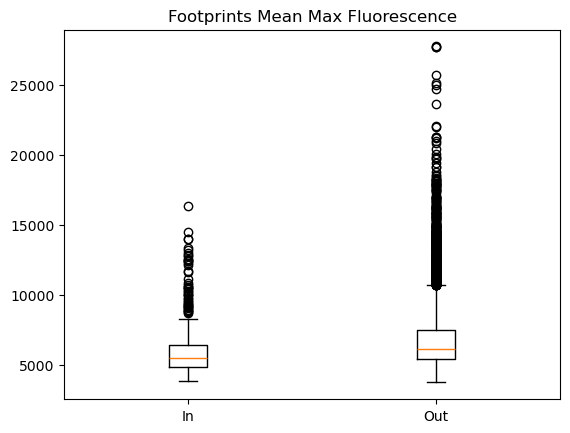

In [ ]:
with open("data/low_affinity_null_means_max.txt", "r") as f:
    null_means_max = [float(x.strip()) for x in f.readlines()]

with open("data/low_affinity_in_probes_vals.txt", "r") as f:
    in_vals_max = [float(x.strip()) for x in f.readlines()]

with open("data/low_affinity_out_probes_vals.txt", "r") as f:
    out_vals_max = [float(x.strip()) for x in f.readlines()]

# In this analysis we are prioritizing the null distribution of the max of the two orientations
print(np.percentile(null_means_max, [90,95,99]))
print(np.mean(in_vals_max))

# Save data to files
# with open("low_affinity_null_means_max.txt", "w") as out_file:
#    for x in null_means_max:
#        out_file.write(str(x) + "\n")

# with open("low_affinity_in_probes_vals.txt", "w") as out_file:
#    for x in in_vals_max:
#        out_file.write(str(x) + "\n")

# with open("low_affinity_out_probes_vals.txt", "w") as out_file:
#    for x in out_vals_max:
#        out_file.write(str(x) + "\n")

# Make a boxplot
plt.boxplot([in_vals_max, out_vals_max], labels = ["In", "Out"])
plt.title("Footprints Mean Max Fluorescence")
# plt.savefig("low_affinity_figure1.png")
plt.show()

In [284]:
# Print some additional statistics
print(np.mean(in_vals_max))
print(np.mean(out_vals_max))
print(np.mean(in_vals_max) - np.mean(out_vals_max))

6183.304146765965
6866.273149291314
-682.9690025253494


In [ ]:
# Low p value
null_less_count = 0
for m in null_means_max:
    if m < np.mean(in_vals_max):
        null_less_count += 1

print(null_less_count / 1000)

0.008


/Users/satusky/anaconda3/envs/data/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


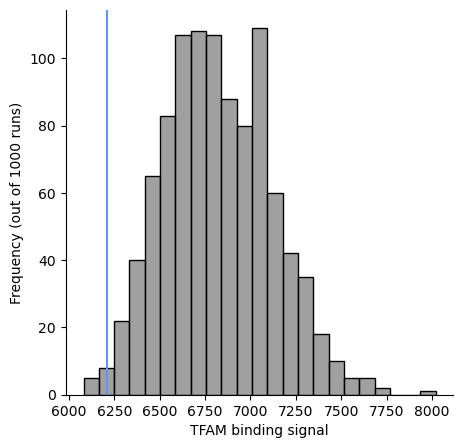

In [ ]:
# Make main histogram plot
fig, ax = plt.subplots(figsize=(5, 5))
h = sns.histplot(null_means_max, ax=ax, color="grey")
ax.axvline(np.mean(in_vals_max),color='cornflowerblue')
ax.set(xlabel="TFAM binding signal", ylabel="Frequency (out of 1000 runs)")
ax.spines[['right', 'top']].set_visible(False)
# plt.title("Maximum Median Adjusted Alexa488 Value")
# plt.legend(["Mean of In Probes", "Null Distribution"])
# plt.savefig("low_affinity_random_distribution.svg")
plt.show()

In [88]:
# Out regions defined as neither low nor high
hf_coords = [[coord[0], coord[1]] for coord in high_regions.values()]
lf_coords = [[coord[0], coord[1]] for coord in low_regions.values()]

# Iterate over c30 and designate values as in or out of TFAM intervals
high_f = []
high_r = []
high_max = []

low_f = []
low_r = []
low_max = []

out_f = [] 
out_r = []
out_max = []

region_markers = np.zeros((len(c30_joined), 2), dtype=bool) # index [0] = low, [1] = high
both = np.zeros(len(c30_joined), dtype=bool)
for i, (index, row) in enumerate(c30_joined.iterrows()):
    if row['end_coord'] < row['start_coord']:
        continue

    for interval in lf_coords:
        # Normal case- can disregard circular case in both the probes and the bedGraph intervals because we know there are no circular bedGraph intervals that span the end and beginning of the mitochondrial genome coordinates, so it is not possible for any circular probes to be entirely contained in a bedGraph interval.
        if interval[0] < interval[1]:
            if (row['start_coord'] >= interval[0] and row['end_coord'] <= interval[1]) or (interval[0] >= row['start_coord'] and interval[1] <= row['end_coord']):
                region_markers[i, 0] = True
                break

    for interval in hf_coords:
        # Normal case- can disregard circular case in both the probes and the bedGraph intervals because we know there are no circular bedGraph intervals that span the end and beginning of the mitochondrial genome coordinates, so it is not possible for any circular probes to be entirely contained in a bedGraph interval.
        if interval[0] < interval[1]:
            if (row['start_coord'] >= interval[0] and row['end_coord'] <= interval[1]) or (interval[0] >= row['start_coord'] and interval[1] <= row['end_coord']):
                region_markers[i, 1] = True
                break
            
    if np.all(region_markers[i]):
        both[i] = True
        print(f"Probe {i}: {index} in both high and low")
    elif region_markers[i, 0]:
        low_f.append(row['norm_median'])
        low_r.append(row['norm_median_r'])
        low_max.append(row['max_norm_median'])
    elif region_markers[i, 1]:
        high_f.append(row['norm_median'])
        high_r.append(row['norm_median_r'])
        high_max.append(row['max_norm_median'])
    else:
        out_f.append(row['norm_median'])
        out_r.append(row['norm_median_r'])
        out_max.append(row['max_norm_median'])

In [89]:
len(high_max), len(low_max), len(out_max)

(136, 326, 7806)

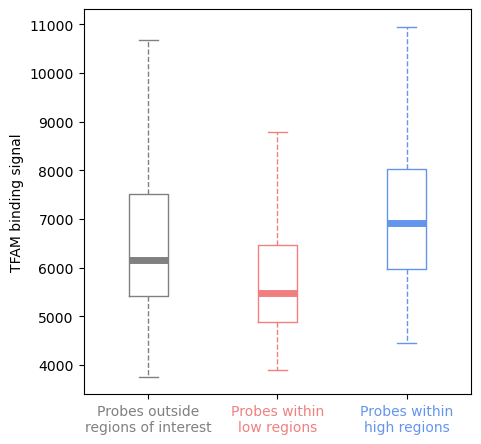

In [ ]:
statbar_height = 0.0005

fig, ax = plt.subplots(figsize=(5, 5))
bp = ax.boxplot(
    [out_max, low_max, high_max],
    labels=[
        "Probes outside\nregions of interest",
        "Probes within\nlow regions",
        "Probes within\nhigh regions"
    ],
    showfliers=False,
    whiskerprops={"linestyle": "--"},
)

bp_colors = ["grey", "lightcoral", "cornflowerblue"]
for i in range(3):
    plt.setp(bp["boxes"][i], color=bp_colors[i])
    plt.setp(bp["medians"][i], color=bp_colors[i], linewidth=5)

    whiskers = [i * 2, i * 2 + 1]
    for whisker in whiskers:
        plt.setp(bp["whiskers"][whisker], color=bp_colors[i])
        plt.setp(bp["caps"][whisker], color=bp_colors[i])

    ax.xaxis.get_ticklabels()[i].set_color(bp_colors[i])

ax.set(ylabel="TFAM binding signal")
# plt.title("Footprints Mean Max Fluorescence")
# plt.savefig("probes_in_isaac_low_v_high_affinity.svg")
plt.show()

In [106]:
mann_out_low = stats.mannwhitneyu(out_max, low_max)
mann_out_high = stats.mannwhitneyu(out_max, high_max)
mann_low_high = stats.mannwhitneyu(low_max, high_max)

print("Mann-Whitney U results")
print(f"Out v Low: {mann_out_low.pvalue}")
print(f"Out v High: {mann_out_high.pvalue}")
print(f"Low v High: {mann_low_high.pvalue}")

Mann-Whitney U results
Out v Low: 3.0113651803994587e-18
Out v High: 8.892222258616437e-05
Low v High: 2.7693334253664163e-13
